# **Notebook for evaluating the case study days**

These were the days saved during index calculation in *CAT_indices-calculation*

There are files for the top 10 days where the accumulative p99 exceedances are greatest, and files for the top 10 timesteps where across the domain there are the most exceedances. Timesteps are all 6-hourly.

**Notebook order of operations:**
 - Plots the case study day and the turbulence index frequencies for the model and case study selected
 - adds relevant meterological variables from the model to understand what was happening on that day



*Maybe to add down the line:* 
 - finding days with similar patters in BARRA and see if that lines up with how models re-create turbulence on those days

In [1]:
# IMPORTS:

import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd())) 
import glob
import importlib
import pickle
import gc

import xarray as xr
import numpy as np
from xarray.groupers import SeasonResampler, SeasonGrouper
import os

import pandas as pd

from IPython.display import display

from matplotlib import colors, cm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import turbulence_AUSCAT.auscat_plots as auscat_plots
from turbulence_AUSCAT.cat_evaluation import combined_significance_table, time_sel_dict, calc_trend_table, select_resample_time
# combined_significance_table is very slow and not at all parallelised. Need to be smarter so it can be run on dask

import datetime
import calendar

from scipy import stats
import math

import dask
from dask.distributed import Client
from dask.diagnostics import ProgressBar
from tqdm.notebook import tqdm
# request 14 cores 64GB


# Setup:

In [2]:
# Basics:
turbulence_index = "TI1"
P = 250
p99 = "mmm-p99"

mmm_p99_dict = {"windspeed": 76.7527,
                "VWS": 0.012295220450099018,
                "Ri": 1.152088,
                "TI1": 2.1185820196367124e-07,
                "TI2": 2.267155e-07,
                "TI3": 2.3883844807661087e-07}

# Model:
list_historical = ['historical_ACCESS-CM2_r4i1p1f1',    #0
                   'historical_ACCESS-ESM1-5_r6i1p1f1', #1
                   'historical_CESM2_r11i1p1f1',        #2
                   'historical_CMCC-ESM2_r1i1p1f1',     #3
                   'historical_EC-Earth3_r1i1p1f1',     #4
                   'historical_MPI-ESM1-2-HR_r1i1p1f1', #5
                   'historical_NorESM2-MM_r1i1p1f1']    #6

model = list_historical[1]  # 0 - 6
model_name = model.split("_")[1]

# Open relevant file:
file_stem = f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/{p99}/case-studies/"
fn = f"{file_stem}{turbulence_index}-{P}hPa-top10-6hr-days_AUS-15_{model}_BOM_BARPA-R_v1-r1_6hr.nc"

ds = xr.open_dataset(fn)
ds

<xarray.Dataset> Size: 542MB
Dimensions:        (event: 10, time: 20, lat: 436, lon: 777)
Coordinates:
  * time           (time) datetime64[ns] 160B 1996-05-13 ... 2014-06-27T18:00:00
  * lon            (lon) float64 6kB 88.04 88.19 88.34 ... 207.6 207.8 207.9
  * lat            (lat) float64 3kB -53.58 -53.42 -53.27 ... 13.32 13.48 13.63
  * event          (event) int64 80B 1 2 3 4 5 6 7 8 9 10
    peak_timestep  (event) datetime64[ns] 80B ...
    peak_count     (event) int64 80B ...
Data variables:
    TI1            (event, time, lat, lon) float64 542MB ...
Attributes:
    Description:  Top 10 days (full 6-hourly) by peak 6-hourly exceedance cou...
    p99:          2.1185820196367124e-07

In [58]:
# Select event for plotting:

da = ds[turbulence_index]   # Select index data

event = da.sel(event=1)     # Select the event --> they are saved 1-10, 1 the most intense, 10 the 10th most intense

# Check time and count of exceedances
peak_time = event.peak_timestep.values      
peak_count = int(event.peak_count.values)

print(f"peak_time={peak_time}, peak_count={peak_count}")

peak_time=2002-02-18T18:00:00.000000000, peak_count=11868


# Plot frequency values for selected model and event:

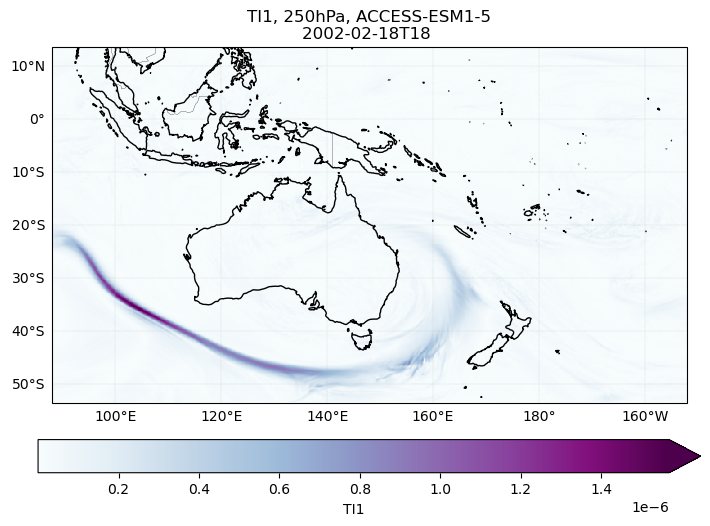

In [59]:
# Plot:

# Pick timeframe of event
field = event.sel(time=peak_time)

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})      #Initialise fig on lat lon map

# Plot data and colour bar
field.plot(ax=ax,transform=ccrs.PlateCarree(), cmap="BuPu", 
           cbar_kwargs={"label": turbulence_index, "orientation": "horizontal", "pad": 0.08, "shrink": 0.95, "extend": "max"})         

# Plot formatting:
ax.set_extent([float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

lons = np.arange(80, 220, 20)
lons_wrapped = ((lons + 180) % 360) - 180 
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--", xlocs=lons_wrapped)
gl.top_labels = False

ax.set_title(
    f"{turbulence_index}, {P}hPa, {model_name}\n"
    f"{np.datetime_as_string(peak_time, unit='h')} ")

plt.show()

# Overlaying meteorlogical variables:

## Winds:

In [60]:
# Load in windspeed data for selected model and timestep:

# Model
source_id = model_name
experiment_id = model.split("_")[0]
member_id = model.split("_")[2]

# Timestep - BARPA files saved by year 
year = pd.Timestamp(peak_time).year

# Helper func for selecting the right BARPA file
def find_barpa_file(varname):
    pattern = (f"/g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/{source_id}/{experiment_id}/{member_id}/"
               f"BARPA-R/v1-r1/6hr/{varname}{P}/v*/"
               f"{varname}{P}_AUS-15_{source_id}_{experiment_id}_{member_id}_BOM_BARPA-R_v1-r1_6hr_{year}01-{year}12.nc")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No match for {pattern}")
    else:
        print(f"{varname}: {matches[0]}")
    
    return matches[0]

# find wind direction files
ua_file = find_barpa_file("ua")
va_file = find_barpa_file("va")

# open them together
ds_wind = xr.open_mfdataset([ua_file, va_file])
ds_wind = ds_wind.convert_calendar("standard")   # keep calendar consistent with the TI1 output

# pick out specific timestep
wind_at_peak = ds_wind.sel(time=peak_time)
windspeed = np.sqrt(wind_at_peak[f"ua{P}"]**2 + wind_at_peak[f"va{P}"]**2).compute()

# make sure grids match and values seem reasonable
print("windspeed grid:", windspeed.shape, "TI1 grid:", field.shape)
print(f"windspeed range: {float(windspeed.min()):.1f} to {float(windspeed.max()):.1f} m/s")



ua: /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/6hr/ua250/v20231001/ua250_AUS-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_6hr_200201-200212.nc
va: /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/6hr/va250/v20231001/va250_AUS-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_6hr_200201-200212.nc
windspeed grid: (436, 777) TI1 grid: (436, 777)
windspeed range: 0.0 to 84.9 m/s


In [ ]:
# All winds contoured (unused plotting script)
'''
cs = ax.contour(
    windspeed.lon, windspeed.lat, windspeed,
    transform=ccrs.PlateCarree(),
    colors="lightgrey",
    linewidths=0.8,
    levels=np.arange(0, 100, 20),   
)
ax.clabel(cs, inline=True, fontsize=7, fmt="%d")
'''

{95: np.float64(59.886766382278665), 99: np.float64(71.72725906533101)}


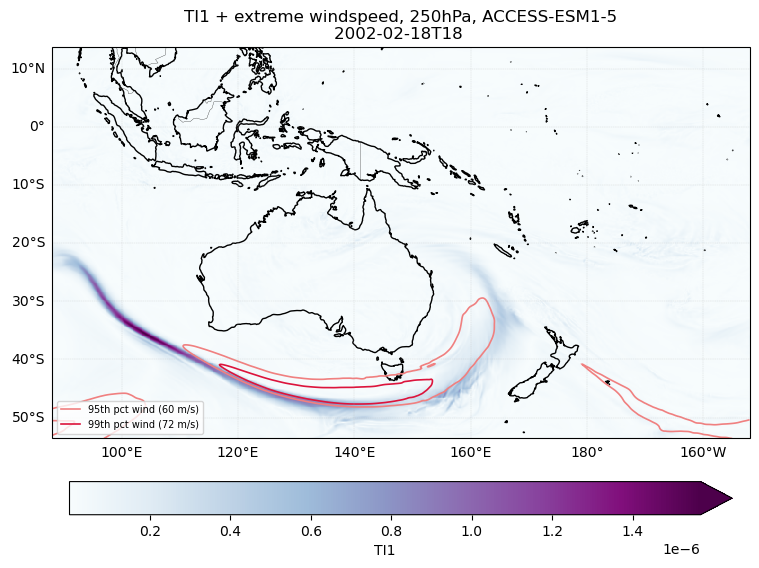

In [61]:
# PLOT

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})

# Plot TI1 data and colour bar
field.plot(ax=ax,transform=ccrs.PlateCarree(), cmap="BuPu", 
           cbar_kwargs={"label": turbulence_index, "orientation": "horizontal", "pad": 0.08, "shrink": 0.95, "extend": "max"})         


# Calculate 99th and 95th percenitle winds
pcts = [95, 99]
levels = np.percentile(windspeed.values, pcts)
colors = ["lightcoral", "crimson"]
print(dict(zip(pcts, levels)))

# Plot the extreme winds
cs = ax.contour(windspeed.lon, windspeed.lat, windspeed, 
                transform=ccrs.PlateCarree(), colors=colors, linewidths=1.2, levels=levels)

# Label for the winds
legend_elements = [Line2D([0], [0], color=c, lw=1.2, label=f"{p}th pct wind ({v:.0f} m/s)")
                   for p, c, v in zip(pcts, colors, levels)]
ax.legend(handles=legend_elements, loc="lower left", fontsize=7, framealpha=0.8)


# Plot formatting
ax.set_extent([float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

lons = np.arange(80, 220, 20)
lons_wrapped = ((lons + 180) % 360) - 180 
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--", xlocs=lons_wrapped)
gl.top_labels = False

ax.set_title(
    f"{turbulence_index} + extreme windspeed, {P}hPa, {model_name}\n"
    f"{np.datetime_as_string(peak_time, unit='h')} ")

plt.show()

## MSLP:

In [62]:
# locate and load MSLP (psl) for the same model/date 

# BARPA file pattern for MSLP
pattern = (
    f"/g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/{source_id}/{experiment_id}/{member_id}/"
    f"BARPA-R/v1-r1/1hr/psl/v*/psl_AUS-15_{source_id}_{experiment_id}_{member_id}_BOM_BARPA-R_v1-r1_1hr_*.nc"
)

all_psl_files = sorted(glob.glob(pattern))
psl_files = [f for f in all_psl_files if str(year) in f]
print(f"Found {len(psl_files)} psl file(s) for {year}:")
for f in psl_files:
    print(" ", f)

ds_psl = xr.open_mfdataset(psl_files)
ds_psl = ds_psl.convert_calendar("standard")

# Select relevant timestep and convert to hPa
mslp_at_peak = (ds_psl["psl"].sel(time=peak_time) / 100).compute()   # Pa -> hPa
print(f"MSLP range: {float(mslp_at_peak.min()):.1f} to {float(mslp_at_peak.max()):.1f} hPa")

Found 1 psl file(s) for 2002:
  /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/1hr/psl/v20231001/psl_AUS-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_1hr_200201-200212.nc
MSLP range: 970.2 to 1025.6 hPa


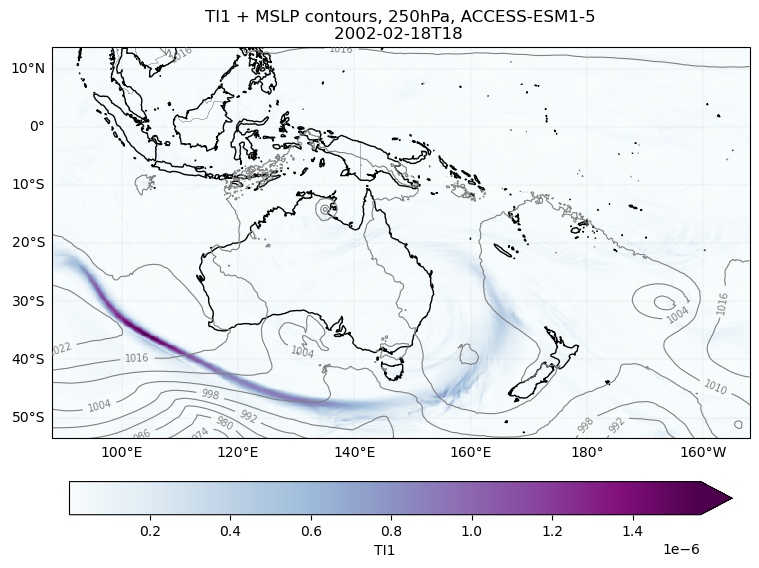

In [63]:
# PLOT

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})

# Plot TI1 data and colour bar
field.plot(ax=ax,transform=ccrs.PlateCarree(), cmap="BuPu", 
           cbar_kwargs={"label": turbulence_index, "orientation": "horizontal", "pad": 0.08, "shrink": 0.95, "extend": "max"})         

# MSLP as contours
cs = ax.contour(
    mslp_at_peak.lon, mslp_at_peak.lat, mslp_at_peak,
    transform=ccrs.PlateCarree(),
    colors="grey",
    linewidths=0.8,
    levels=np.arange(950, 1040, 6),  
)
ax.clabel(cs, inline=True, fontsize=7, fmt="%d")

# Plot formatting
ax.set_extent([float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

lons = np.arange(80, 220, 20)
lons_wrapped = ((lons + 180) % 360) - 180
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, xlocs=lons_wrapped, linestyle="--")
gl.top_labels = False

ax.set_title(
    f"{turbulence_index} + MSLP contours, {P}hPa, {model_name}\n"
    f"{np.datetime_as_string(peak_time, unit='h')} ")

plt.show()

## Geopotential height:

In [64]:
# locate and load geopotential height (zg) for the same model/date

# BARPA file pattern for zg at 250hPa
pattern = (
    f"/g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/{source_id}/{experiment_id}/{member_id}/"
    f"BARPA-R/v1-r1/6hr/zg{P}/v*/zg{P}_AUS-15_{source_id}_{experiment_id}_{member_id}_BOM_BARPA-R_v1-r1_6hr_*.nc"
)

all_zg_files = sorted(glob.glob(pattern))
zg_files = [f for f in all_zg_files if str(year) in f]
print(f"Found {len(zg_files)} zg file(s) for {year}:")
for f in zg_files:
    print(" ", f)

ds_zg = xr.open_mfdataset(zg_files)
ds_zg = ds_zg.convert_calendar("standard")

# Select relevant timestep (metres, no unit conversion needed)
zg_at_peak = (ds_zg[f"zg{P}"].sel(time=peak_time)).compute()
print(f"zg range: {float(zg_at_peak.min()):.0f} to {float(zg_at_peak.max()):.0f} m")



Found 1 zg file(s) for 2002:
  /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/6hr/zg250/v20231001/zg250_AUS-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_6hr_200201-200212.nc
zg range: 9789 to 11130 m


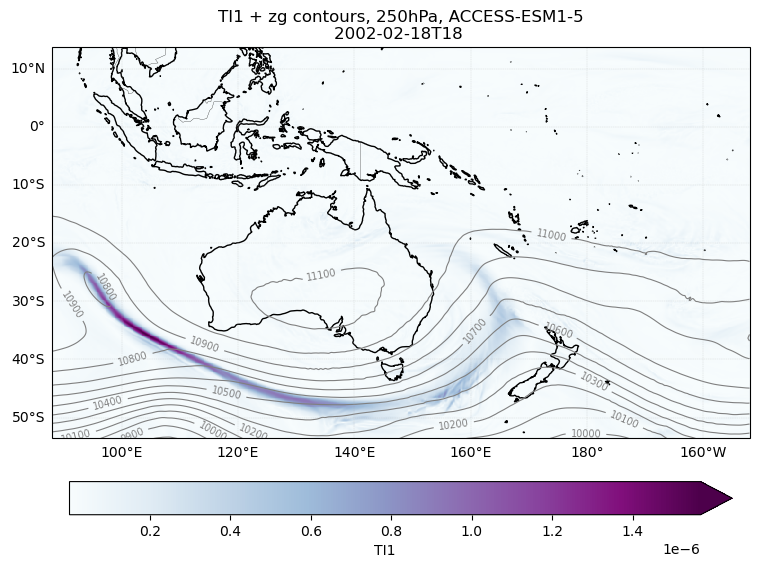

In [65]:
# PLOT

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})

# Plot TI1 data and colour bar
field.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="BuPu",
           cbar_kwargs={"label": turbulence_index, "orientation": "horizontal", "pad": 0.08, "shrink": 0.95, "extend": "max"})

# zg as contours
cs = ax.contour(
    zg_at_peak.lon, zg_at_peak.lat, zg_at_peak,
    transform=ccrs.PlateCarree(),
    colors="grey",
    linewidths=0.8,
    levels=np.arange(9700, 12000, 100),
)
ax.clabel(cs, inline=True, fontsize=7, fmt="%d")

# Plot formatting
ax.set_extent([float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

lons = np.arange(80, 220, 20)
lons_wrapped = ((lons + 180) % 360) - 180
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, xlocs=lons_wrapped, linestyle="--")
gl.top_labels = False

ax.set_title(
    f"{turbulence_index} + zg contours, {P}hPa, {model_name}\n"
    f"{np.datetime_as_string(peak_time, unit='h')} ")

plt.show()

# Next: Finding way to plot them together nicely? then combine into 7 panel plot.

# Is there a shared day between indices?

In [3]:
P = 250

# Model:
list_historical = ['historical_ACCESS-CM2_r4i1p1f1',    #0
                   'historical_ACCESS-ESM1-5_r6i1p1f1', #1
                   'historical_CESM2_r11i1p1f1',        #2
                   'historical_CMCC-ESM2_r1i1p1f1',     #3
                   'historical_EC-Earth3_r1i1p1f1',     #4
                   'historical_MPI-ESM1-2-HR_r1i1p1f1', #5
                   'historical_NorESM2-MM_r1i1p1f1']    #6

results = []

for run in list_historical:
    _, source_id, _ = run.split("_")

    ti1_file = (f"/scratch/v46/ls7238/CAT_turbulence/TI1/{P}hPa/mmm-p99/case-studies/"
                f"TI1-{P}hPa-top10-6hr-days_AUS-15_{run}_BOM_BARPA-R_v1-r1_6hr.nc")
    vws_file  = (f"/scratch/v46/ls7238/CAT_turbulence/VWS/{P}hPa/mmm-p99/case-studies/"
                f"VWS-{P}hPa-top10-6hr-days_AUS-15_{run}_BOM_BARPA-R_v1-r1_6hr.nc")

    if not os.path.exists(ti1_file) or not os.path.exists(vws_file):
        print(f"  {source_id}: missing file — skipping")
        continue

    with xr.open_dataset(ti1_file) as ds:
        ti1_dates = {pd.Timestamp(t).strftime("%Y-%m-%d")
                     for t in ds["peak_timestep"].values}

    with xr.open_dataset(vws_file) as ds:
        ws_dates  = {pd.Timestamp(t).strftime("%Y-%m-%d")
                     for t in ds["peak_timestep"].values}

    overlap = sorted(ti1_dates & ws_dates)

    if overlap:
        for date in overlap:
            results.append({"Model": source_id, "Shared date": date})
        print(f"  {source_id}: {len(overlap)} shared — {overlap}")
    else:
        print(f"  {source_id}: no shared days")

print()
if results:
    display(pd.DataFrame(results).style.hide(axis="index")
            .set_caption("Days appearing in both TI1 and windspeed top-10"))
else:
    print("No shared days found across any model.")


  ACCESS-CM2: no shared days
  ACCESS-ESM1-5: 1 shared — ['2009-06-29']
  CESM2: 5 shared — ['1992-06-28', '1992-06-29', '2001-05-15', '2008-06-29', '2011-07-02']
  CMCC-ESM2: 2 shared — ['2002-06-22', '2002-06-23']
  EC-Earth3: 2 shared — ['2001-07-21', '2001-07-22']
  MPI-ESM1-2-HR: 2 shared — ['1999-06-16', '2004-07-17']
  NorESM2-MM: 1 shared — ['2003-07-08']



Model,Shared date
ACCESS-ESM1-5,2009-06-29
CESM2,1992-06-28
CESM2,1992-06-29
CESM2,2001-05-15
CESM2,2008-06-29
CESM2,2011-07-02
CMCC-ESM2,2002-06-22
CMCC-ESM2,2002-06-23
EC-Earth3,2001-07-21
EC-Earth3,2001-07-22


['historical_ACCESS-CM2_r4i1p1f1',   
'historical_ACCESS-ESM1-5_r6i1p1f1', 
'historical_CESM2_r11i1p1f1',       
'historical_CMCC-ESM2_r1i1p1f1',     
'historical_EC-Earth3_r1i1p1f1',     
'historical_MPI-ESM1-2-HR_r1i1p1f1',
'historical_NorESM2-MM_r1i1p1f1']

In [15]:
# flexible script - just tweak model and date

# Set-up
run = 'historical_NorESM2-MM_r1i1p1f1'
P = 250
p99 = "mmm-p99"
shared_date = "2003-07-08"

source_id = run.split("_")[1]   
experiment_id = run.split("_")[0]   
member_id = run.split("_")[2]   

# Helper: open the field of data for the given date
def get_field_for_date(turbulence_index, run, shared_date, P, p99):

    file = (f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/{p99}/case-studies/"
               f"{turbulence_index}-{P}hPa-top10-6hr-days_AUS-15_{run}_BOM_BARPA-R_v1-r1_6hr.nc")

    # Option 1: case stuy hasnt been saved for this turb index
    if not os.path.exists(file):
        print(f"{turbulence_index}: no case study file found")
        return None, None

    # Option 2: file has been saved and date is there
    with xr.open_dataset(file) as ds:
        for event in ds.event.values:
            t = pd.Timestamp(ds["peak_timestep"].sel(event=event).values)
            if t.strftime("%Y-%m-%d") == shared_date:
                peak_time = ds["peak_timestep"].sel(event=event).values
                field = ds[turbulence_index].sel(event=event, time=peak_time).compute()
                print(f"{turbulence_index}: rank {int(event)}, timestep: {pd.Timestamp(peak_time)}, count: {int(ds['peak_count'].sel(event=event).values)}")

                return field, peak_time

    # Option 3: There is a file but the shared date is not in it.
    print(f"  {turbulence_index}: {shared_date} not in top-10 case studies")
    return None, None

print("Loading index data...")
ti1_field, peak_time = get_field_for_date("TI1", run, shared_date, P, p99)
vws_field, _ = get_field_for_date("VWS", run, shared_date, P, p99)

# load wind from model
year = pd.Timestamp(peak_time).year

def find_barpa_file(varname):
    pattern = (f"/g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/{source_id}/{experiment_id}/{member_id}/BARPA-R/v1-r1/6hr/{varname}{P}/v*/"
               f"{varname}{P}_AUS-15_{source_id}_{experiment_id}_{member_id}_BOM_BARPA-R_v1-r1_6hr_{year}01-{year}12.nc")
    matches = glob.glob(pattern)

    if not matches:
        raise FileNotFoundError(f"No match for {pattern}")

    print(f"{varname}: {matches[0]}")
    return matches[0]

print("\nLoading wind...")
ds_wind = xr.open_mfdataset([find_barpa_file("ua"), find_barpa_file("va")]).convert_calendar("standard")
wind_peak = ds_wind.sel(time=peak_time)
windspeed = np.sqrt(wind_peak[f"ua{P}"]**2 + wind_peak[f"va{P}"]**2).compute()

pcts = [95, 99]
levels = np.percentile(windspeed.values, pcts)
colors = ["lightcoral", "crimson"]
print(f"\nWindspeed percentiles: { {p: f'{v:.1f} m/s' for p, v in zip(pcts, levels)} }")


Loading index data...
TI1: rank 10, timestep: 2003-07-08 12:00:00, count: 8632
VWS: rank 9, timestep: 2003-07-08 12:00:00, count: 11150

Loading wind...
ua: /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/NorESM2-MM/historical/r1i1p1f1/BARPA-R/v1-r1/6hr/ua250/v20231001/ua250_AUS-15_NorESM2-MM_historical_r1i1p1f1_BOM_BARPA-R_v1-r1_6hr_200301-200312.nc
va: /g/data/py18/BARPA/output-CMIP6/DD/AUS-15/BOM/NorESM2-MM/historical/r1i1p1f1/BARPA-R/v1-r1/6hr/va250/v20231001/va250_AUS-15_NorESM2-MM_historical_r1i1p1f1_BOM_BARPA-R_v1-r1_6hr_200301-200312.nc

Windspeed percentiles: {95: '69.5 m/s', 99: '87.1 m/s'}


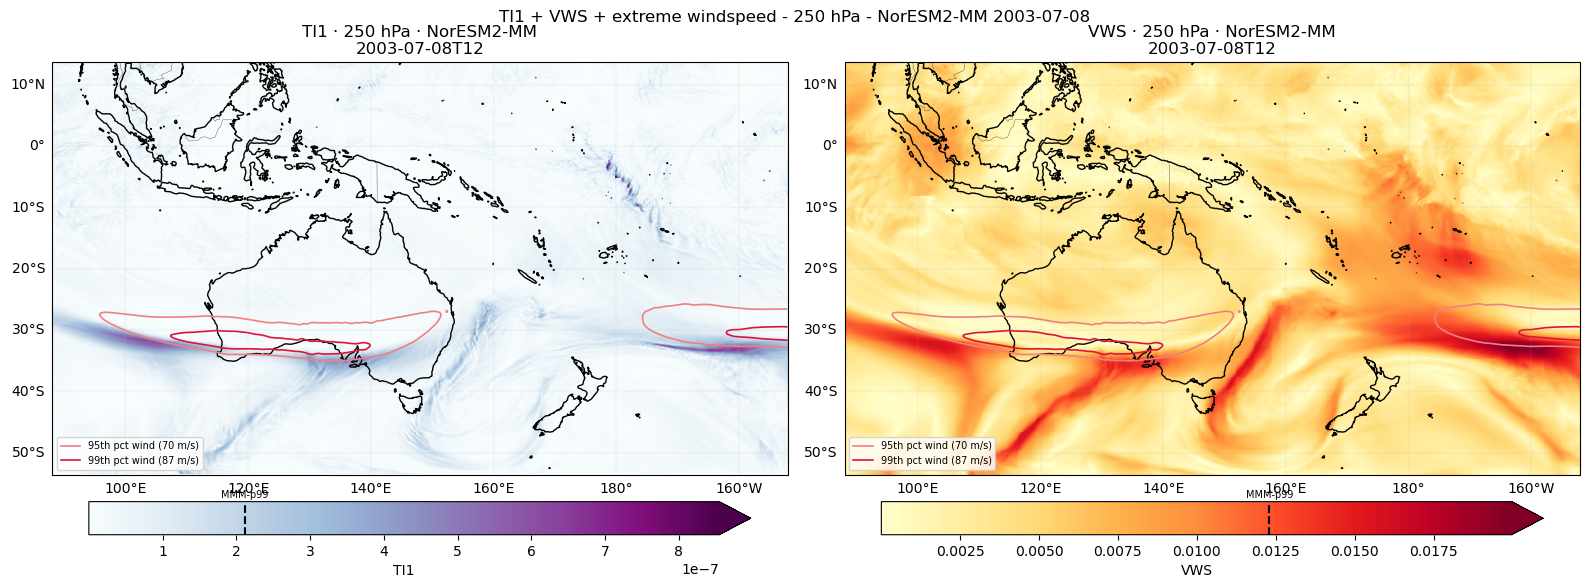

In [16]:
# 2 PANEL PLOT

p99_vals = {"TI1": mmm_p99_dict["TI1"], "VWS": mmm_p99_dict["VWS"]}
panels = [(ti1_field, "TI1", "BuPu"), (vws_field, "VWS", "YlOrRd")]
proj = ccrs.PlateCarree(central_longitude=180)

fig, axs = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": proj})

legend_elements = [Line2D([0], [0], color=c, lw=1.2, label=f"{p}th pct wind ({v:.0f} m/s)") for p, c, v in zip(pcts, colors, levels)]

# if there is no data
for ax, (field, label, cmap) in zip(axs, panels):
    if field is None:
        ax.text(0.5, 0.5, f"{label}\nnot available for {shared_date}", ha="center", va="center", transform=ax.transAxes, fontsize=11)
        continue

    # plot data
    p = field.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,       
                   cbar_kwargs={"label": label, "orientation": "horizontal", "pad": 0.05, "shrink": 0.9, "extend": "max"})

    # label p99
    p99 = p99_vals[label]
    p.colorbar.ax.axvline(x=p99, color="k", linewidth=1.5, linestyle="--")
    p.colorbar.ax.text(p99, 1.05, "MMM-p99", transform=p.colorbar.ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=7)

    ax.contour(windspeed.lon, windspeed.lat, windspeed,
               transform=ccrs.PlateCarree(), colors=colors,
               linewidths=1.2, levels=levels)

    ax.set_extent([float(windspeed.lon.min()), float(windspeed.lon.max()),
                   float(windspeed.lat.min()), float(windspeed.lat.max())],
                  crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    lons_wrapped = ((np.arange(80, 220, 20) + 180) % 360) - 180
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
                      linestyle="--", xlocs=lons_wrapped)
    gl.top_labels = False
    gl.right_labels = False

    ax.legend(handles=legend_elements, loc="lower left", fontsize=7, framealpha=0.8)
    ax.set_title(f"{label} · {P} hPa · {source_id}\n"
                 f"{np.datetime_as_string(peak_time, unit='h')}")

fig.suptitle(f"TI1 + VWS + extreme windspeed - {P} hPa - {source_id} {shared_date}", fontsize=12)
plt.tight_layout()
plt.show()